In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import IncrementalPCA
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import cv2
import joblib
import matplotlib.pyplot as plt
import time
from einops import rearrange
from IPython.display import clear_output
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])
from useful_stuff.general_utils.utils import print_wise, is_empty
from useful_stuff.image_processing.utils import get_relevant_output_layers, get_video_dimensions, read_video, load_timm_model, pool_features
# from image_processing.utils import concatenate_frames_batch, shuffle_frames
from image_processing.gaze_dep_models import extract_center_patches, sample_random_patches, capture_1917_movie_runs, extract_features_1917_movie


In [2]:
from dataclasses import dataclass, field

device = 'mps'
@dataclass
class Cfg:
    sq_size = 384
    input_size = 384
    secs_to_skip = 5
    patches_layout = (1,3)
    batch_size = 100
    frames_step = 3 # every how many frames we want to take a sample (due to high temporal autocorrelation we can skip)
    patches_overhead_sampling = 2 # how many patches we want more than the images we're gonna pass to the model (to avoid proper shuffling)
    tot_patches = 3
    n_components = 30
    model_name = 'vit_l_16'
    pooling = "mean"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, 'timm')

# backbone
1. capture the three vids
2. randomly select the moment in the movie for each of the three parts
3. read the frames (decide how many)
4. For each of the frame select the center patches and a random subset of patches (always considering the center but without overlap - maybe since H=522 we'll have a bit of overlap) 
5. shuffle with previous storage and extract features



In [3]:
model = load_timm_model(cfg.model_name, device='mps')
layer_name = layers[0]
feature_extractor = create_feature_extractor(
    model, return_nodes=[layer_name]
).to(device)


# TODO make it a function and subfunctions and run it in parallel

In [102]:
from sklearn.decomposition import IncrementalPCA
ipca_obj = IncrementalPCA(n_components=cfg.n_components, batch_size=cfg.batch_size)
stim_dir = f"{paths['data_path']}/stimuli"
filenames = os.listdir(stim_dir)
n_movies = len(filenames)
caps_list = []
for fn in filenames:
    fn_path = f"{stim_dir}/{fn}"
    cap = cv2.VideoCapture(fn_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {fn_path}")
    # end if not cap.isOpened():
    caps_list.append(cap)
# end for fn in filenames:
fps = cap.get(cv2.CAP_PROP_FPS)
frames_to_skip = round(5*fps)
frames_per_run = []
for cap in caps_list:
    _, _, n_frames = get_video_dimensions(cap)
    frames_per_run.append(n_frames)
# end for cap in caps_list:

patches_per_frame = n_movies*cfg.tot_patches/cfg.frames_step
patches_to_read = cfg.batch_size + round(cfg.batch_size*cfg.patches_overhead_sampling) # the number of patches we have to read at every step
frames_to_read_per_movie = round(patches_to_read/patches_per_frame) # the number of patches we have to read at every step
seconds_to_read_per_movie = frames_to_read_per_movie/fps
max_frames = max(frames_per_run)
min_frames = min(frames_per_run)
batch_starts = np.arange(frames_to_skip, max_frames, frames_to_read_per_movie)
while True: # little check that we don't surpass the three videos in the first 10 steps
    np.random.shuffle(batch_starts)
    mask = batch_starts[:10] < min_frames - cfg.batch_size
    if np.all(mask):
        break
    # end if np.all(mask):
# end while True:
tot_frames = None
for start_f in batch_starts:
    start_s = start_f/fps
    for cap, tot_f in zip(caps_list, frames_per_run):
        if start_f < tot_f:
            end_f = min(start_f+frames_to_read_per_movie, tot_f) # because we might surpass the end of the video
            end_s = end_f/fps
            v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
            v = v[0:-1:cfg.frames_step]
            v = extract_center_patches(v, sq_size)
            if tot_frames is None:
                tot_frames = v
            else:
                tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
            # end if tot_frames is None:
    print(f"before deleting {len(tot_frames)=}")
    chunk = sample_random_patches(tot_frames, cfg.batch_size)
    with torch.no_grad():
        chunk = feature_extractor(chunk)[layer_name]
    chunk = chunk.cpu().detach().numpy()
    chunk = chunk.reshape(chunk.shape[0], -1, order='F')
    print("dont delete now!")
    time.sleep(1)
    ipca_obj.fit(chunk)
    print(f"after deleting {len(tot_frames)=}")
    print("delete now!")
    time.sleep(2)
for b in np.arange(0, len(tot_frames) - cfg.batch_size, cfg.batch_size):
    chunk = sample_random_patches(tot_frames, cfg.batch_size)
    with torch.no_grad():
        chunk = feature_extractor(chunk)[layer_name]
    chunk = chunk.cpu().detach().numpy()
    chunk = chunk.reshape(chunk.shape[0], -1, order='F')
    print("dont delete now!")
    time.sleep(1)
    ipca_obj.fit(chunk)
    print(f"after deleting {len(tot_frames)=}")
    print("delete now!")
    time.sleep(2)


#loop through (and add an if step > n_frames: dont read this time)

before deleting len(tot_frames)=297
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=197
delete now!
before deleting len(tot_frames)=494
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=394
delete now!
before deleting len(tot_frames)=691
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=591
delete now!
before deleting len(tot_frames)=888
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=788
delete now!
before deleting len(tot_frames)=1085
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=985
delete now!
before deleting len(tot_frames)=1282
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=1182
delete now!
before deleting len(tot_frames)=1479
torch.Size([100, 384, 384, 3])
dont delete now!
after deleting len(tot_frames)=1379
delete now!
before deleting len(tot_frames)=1676
torch.Size([100, 384, 384, 3])
dont delet

KeyboardInterrupt: 

In [4]:
from sklearn.decomposition import IncrementalPCA

# input:
# paths, rank, layer_name, model, n_components, batch_size, tot_patches, frames_step, sq_size, input_size, pooling
ipca_obj = IncrementalPCA(n_components=cfg.n_components, batch_size=cfg.batch_size)
caps_list = capture_1917_movie_runs(paths)
n_movies = len(caps_list)
fps = caps_list[0].get(cv2.CAP_PROP_FPS)
frames_to_skip = round(5*fps)
frames_per_run = []
for cap in caps_list:
    _, _, n_frames = get_video_dimensions(cap)
    frames_per_run.append(n_frames)
# end for cap in caps_list:
patches_per_frame = n_movies*cfg.tot_patches/cfg.frames_step
patches_to_read = cfg.batch_size + round(cfg.batch_size*cfg.patches_overhead_sampling) # the number of patches we have to read at every step
frames_to_read_per_movie = round(patches_to_read/patches_per_frame) # the number of patches we have to read at every step
seconds_to_read_per_movie = frames_to_read_per_movie/fps
max_frames = max(frames_per_run)
min_frames = min(frames_per_run)
batch_starts = np.arange(frames_to_skip, max_frames, frames_to_read_per_movie)
while True: # little check that we don't surpass the three videos in the first 10 steps
    np.random.shuffle(batch_starts)
    mask = batch_starts[:10] < min_frames - cfg.batch_size
    if np.all(mask):
        break
    # end if np.all(mask):
# end while True:
tot_frames = None
for start_f in batch_starts: # sample from the whole movies
    start_s = start_f/fps
    for cap, tot_f in zip(caps_list, frames_per_run): # for each of the movies in the caps_list, it reads the frames at that point
        if start_f < tot_f: # enter here only if the current start is in the movie
            end_f = min(start_f+frames_to_read_per_movie, tot_f) # because we might surpass the end of the video
            end_s = end_f/fps
            v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
            v = v[::cfg.frames_step]
            v = extract_center_patches(v, cfg.sq_size)
            if tot_frames is None:
                tot_frames = v
            else:
                tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
            # end if tot_frames is None:
    batch = sample_random_patches(tot_frames, cfg.batch_size)
    features = extract_features_1917_movie(batch, feature_extractor, layer_name, cfg.input_size, pooling=cfg.pooling, device='mps')
    print("stop deleting!")
    time.sleep(2)
    ipca_obj.fit(features)
    print("delete now!")
    time.sleep(2)
# end for start_f in batch_starts:
    
for b in np.arange(0, len(tot_frames) - cfg.batch_size, cfg.batch_size): # process the remaining overhead
    batch = sample_random_patches(tot_frames, cfg.batch_size)
    features = extract_features_1917_movie(batch, feature_extractor, layer_name, pooling=cfg.pooling)
    ipca_obj.fit(features)
    


#loop through (and add an if step > n_frames: dont read this time)

torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([100, 384, 384, 3])
stop deleting!
delete now!
torch.Size([10

KeyboardInterrupt: 

In [170]:
b = preprocess_batch(batch, 224)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0493176..1.0732398].


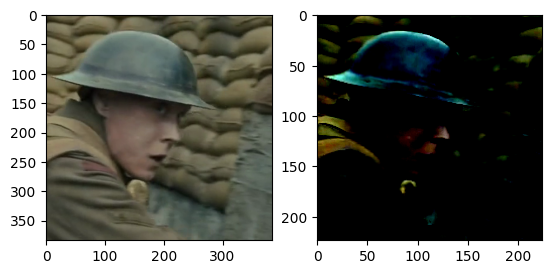

In [183]:
fig, ax = plt.subplots(1, 2)
i = 3
ax[0].imshow(batch[i,:,:,:].cpu())
ax[1].imshow(b[i, :, :, :].cpu().permute(1,2,0));


In [18]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

torch.cuda.empty_cache()
tot_frames = []
for start_f in [batch_starts[1],]:
    start_s = start_f/fps
    for cap, tot_f in zip(caps_list, frames_per_run):
        if start_f < tot_f:
            end_f = min(start_f+frames_to_read_per_movie, tot_f) # because we might surpass the end of the video
            end_s = end_f/fps
            v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
            v = v[::cfg.frames_step]
            v = extract_center_patches(v, cfg.sq_size)
            if tot_frames is None:
                tot_frames = v
            else:
                tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
            # end if tot_frames is None:
    print(f"before deleting {len(tot_frames)=}")
    chunk = sample_random_patches(tot_frames, 100)

chunk_mod = extract_features_1917_movie(chunk, feature_extractor, layer_name, cfg.input_size, cfg.pooling, device='mps')

pts = chunk_mod @ipca_obj.components_.T 


before deleting len(tot_frames)=306
torch.Size([100, 384, 384, 3])


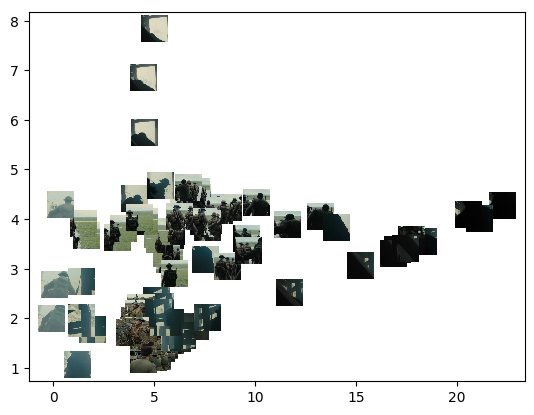

In [20]:
fig, ax = plt.subplots()

# scatter points (optional, for reference)
dims = (0,1)
ax.scatter(pts[:, dims[0]], pts[:, dims[1]])

# overlay images
for i in range(pts.shape[0]):
    # ensure image is in (H, W, C) and in [0,1] or [0,255]
    x = pts[i, dims[0]]
    y = pts[i, dims[1]]
    c = chunk[i, :].detach().cpu().numpy()
    # m = np.abs(c).max()
    # c_min, c_max = c.min(), c.max()
    # img = (c - c_min) / (c_max - c_min + 1e-8)
    # img = c.transpose(1,2,0)
    image = OffsetImage(c, zoom=0.05, alpha=1)

    ab = AnnotationBbox(image, (x, y), frameon=False)
    ax.add_artist(ab)

plt.show()

In [104]:
def get_layer_output_shape(feature_extractor, layer_name, imsize=224):
    with torch.no_grad():
        in_proxy = torch.randn(1, 3, imsize, imsize).to(device)
        tmp_shape = feature_extractor(in_proxy)[layer_name].shape[1:]
    return tmp_shape
# EOF 

get_layer_output_shape(feature_extractor, layers[0], imsize=384)

torch.Size([577, 1024])

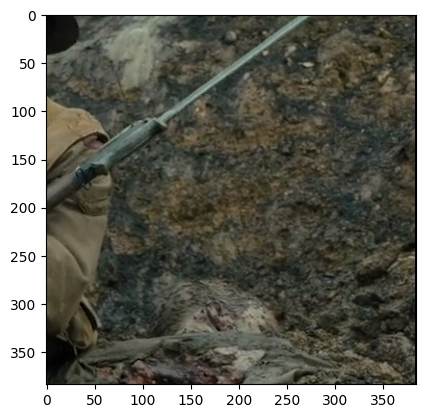

In [92]:
plt.imshow(chunk[0,:].reshape(3, 384, 384, order='F').transpose(1,2,0))

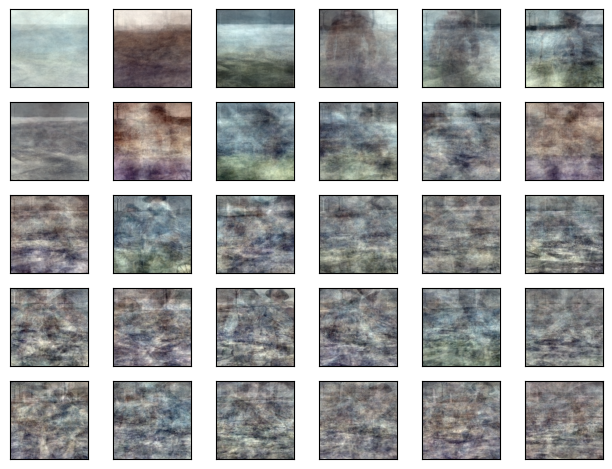

In [97]:
components = ipca_obj.components_
fig, axes = plt.subplots(5, 6)
axes = axes.ravel()
for i, ax in zip(range(cfg.n_components), axes):
    c = components[i, :]    
    c = c.reshape(3, cfg.sq_size, cfg.sq_size, order='F').transpose(1,2,0)
    m = np.abs(c).max()
    c = (c + m) / (2 * m)
    ax.imshow(c)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

In [46]:
3*np.sum(frames_per_run)/frames_step

np.float64(36619.2)

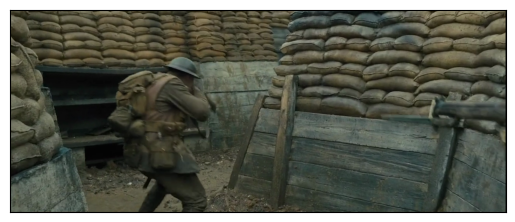

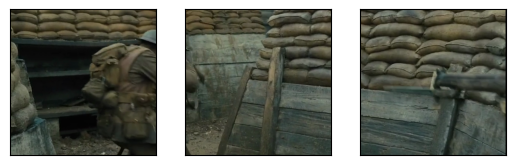

In [ ]:

try:
    for frame in v:
    # frame = v[1]
        h, w, c = frame.shape

        sq_size = 384
        d = (w - 3 * sq_size) // 4
        cy = h // 2
        cx1 = 2*d + sq_size//2
        cx2 = cx1 + d + sq_size
        cx3 = cx2 + d + sq_size
        cxs = [cx1, cx2, cx3]
        ps = []
        for cx in cxs:
            ps.append(extract_square_patch(frame, cx, cy, sq_size))
        plt.imshow(frame)
        plt.xticks([])
        plt.yticks([])
        fig, axes =plt.subplots(1, len(ps))
        for idx, ax in enumerate(axes):
            ax.imshow(ps[idx])
            ax.set_xticks([])
            ax.set_yticks([])
        plt.show()
        clear_output(wait=True)
        time.sleep(.5)
except KeyboardInterrupt:
    pass        

In [89]:
while True:
    np.random.shuffle(batch_starts)
    mask = batch_starts[:10] < min_frames -batch_size
    if np.all(mask):
        break
    else:
        print(1)

1


In [13]:
def ipca_videos(paths, rank, layer_name, model_name, model, n_components, video_type, batches_to_proc, batch_sizes, fn_list, long_vids,  device, vid_duration_lim, new_h=224, new_w=224):
    save_name = (f"{video_type}_{model_name}_{layer_name}_ipca_{n_components}_PCs.pkl")
    path = os.path.join(f"{paths["livingstone_lab"]}/tiziano/models", save_name)
    if os.path.exists(path):
        print_wise(f"{path} already exists")
    else:
        print_wise(f"Fitting PCA for layer: {layer_name}", rank=rank)
        frames_batch = []
        feature_extractor = create_feature_extractor(
            model, return_nodes=[layer_name]
        ).to(device)
        tmp_shape = get_layer_output_shape(feature_extractor, layer_name)
        n_features = np.prod(tmp_shape)  # [C, H, W] -> C*H*W
        n_components_layer = min(n_features, n_components)  # Limit to number of features
        ipca = IncrementalPCA(n_components=n_components_layer, batch_size=batch_sizes[0])
        curr_video_idx = 0
        for idx, curr_batch_size in enumerate(batch_sizes):

            print_wise(f"starting batch {idx}", rank=rank)
            frames_batch, curr_video_idx = concatenate_frames_batch(paths, rank, fn_list, frames_batch, curr_video_idx, idx, batches_to_proc, batch_sizes, new_h, new_w, long_vids, vid_duration_lim)
            frames_batch = shuffle_frames(frames_batch)
            inputs = frames_batch[:curr_batch_size, :, :, :]
            inputs = torch.from_numpy(inputs).float().to(device)
            inputs = inputs.permute(0, 3, 1, 2)
            frames_batch = frames_batch[curr_batch_size:, :, :, :]
            with torch.no_grad():
                feats = feature_extractor(inputs)[layer_name]
                print_wise(f"features shape: {feats.shape}", rank=rank)
                feats = feats.reshape(feats.size(0), -1).cpu().numpy()
            ipca.partial_fit(feats)
            # end with torch.no_grad():
        
        joblib.dump(ipca, path) 
        print_wise(f"Saved PCA for {layer_name} at {path}", rank=rank)


In [ ]:
def concatenate_frames_batch(paths, rank, fn_list, frames_batch, curr_video_idx, curr_batch_idx, batches_to_proc_togeth, batch_sizes, new_h, new_w, long_vids, vid_duration_lim=20, normalize=True):
    n_batches = len(batch_sizes)
    idx_tot = [curr_batch_idx + i for i in range(batches_to_proc_togeth) if curr_batch_idx + i < n_batches] # takes the next $batches_to_proc frames filtering for out of range indices 
    curr_tot_batch_size = np.sum(batch_sizes[idx_tot])
    cumulative_frames_sum = 0
    if is_empty(frames_batch):
        frames_batch = [] # otherwise we have arrays of inconsistent size to concatenate
    else:
        cumulative_frames_sum += frames_batch.shape[0]
        frames_batch = [frames_batch] # makes it a list with all the frames remained from the previous batch (ideally we read 3 batches and shuffle)
    # end if frames_batch:
    while cumulative_frames_sum < curr_tot_batch_size:
        fn = fn_list[curr_video_idx]
        if long_vids[curr_video_idx]: # if the video is marked as long
            video = read_video(paths, rank, fn, vid_duration=vid_duration_lim) # if the video is too long, we just process the beginning (vid_duration_lim is in sec)
        else:
            video = read_video(paths, rank, fn, vid_duration=0)
        # end if long_vids[progression]: 
        video = resize_video_array(video, new_h, new_w, normalize=False)
        curr_video_idx += 1
        curr_frames_n = video.shape[0] 
        cumulative_frames_sum += curr_frames_n
        frames_batch.append(video)
    # end while cumulative_frames_sum < curr_tot_batch_size:
    frames_batch = np.concatenate(frames_batch, axis=0)
    return frames_batch, curr_video_idx
# EOF
